# Harmonic Oscillator 문제에 대한 풀이

# Case 1. 저항이 없는 경우

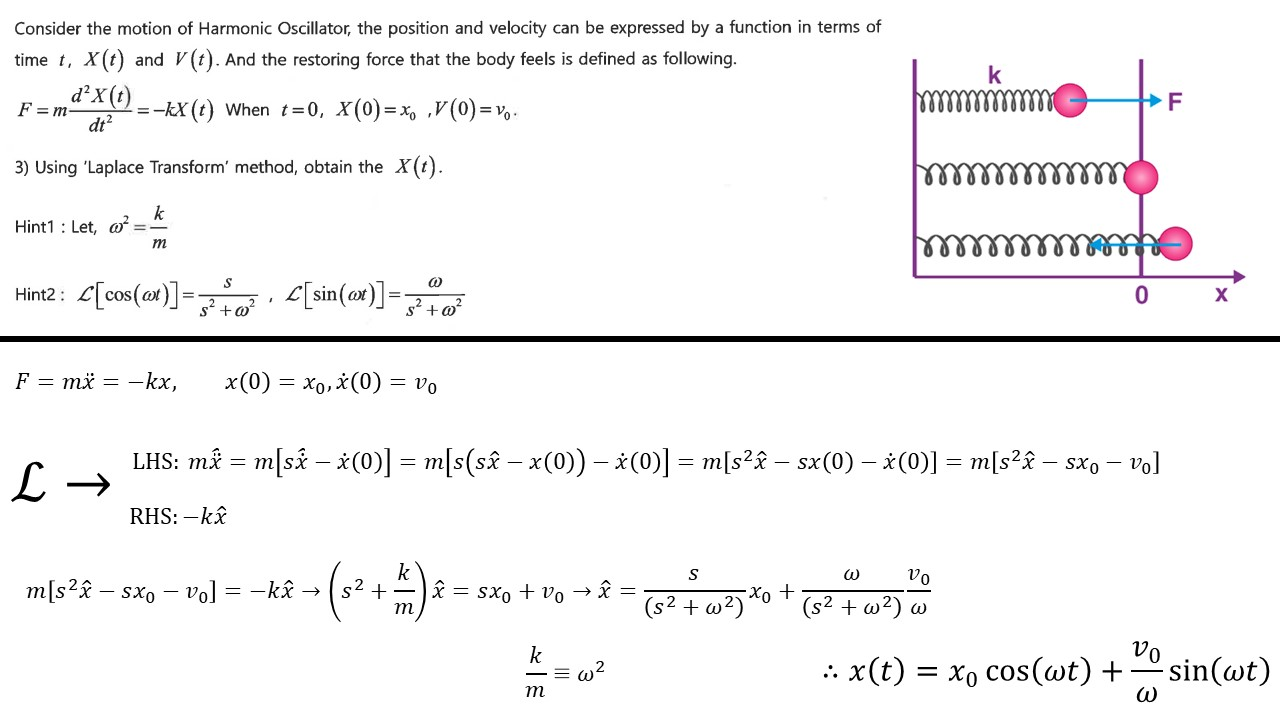

# Case 2. Dragging Force 라는 저항이 있는 경우.

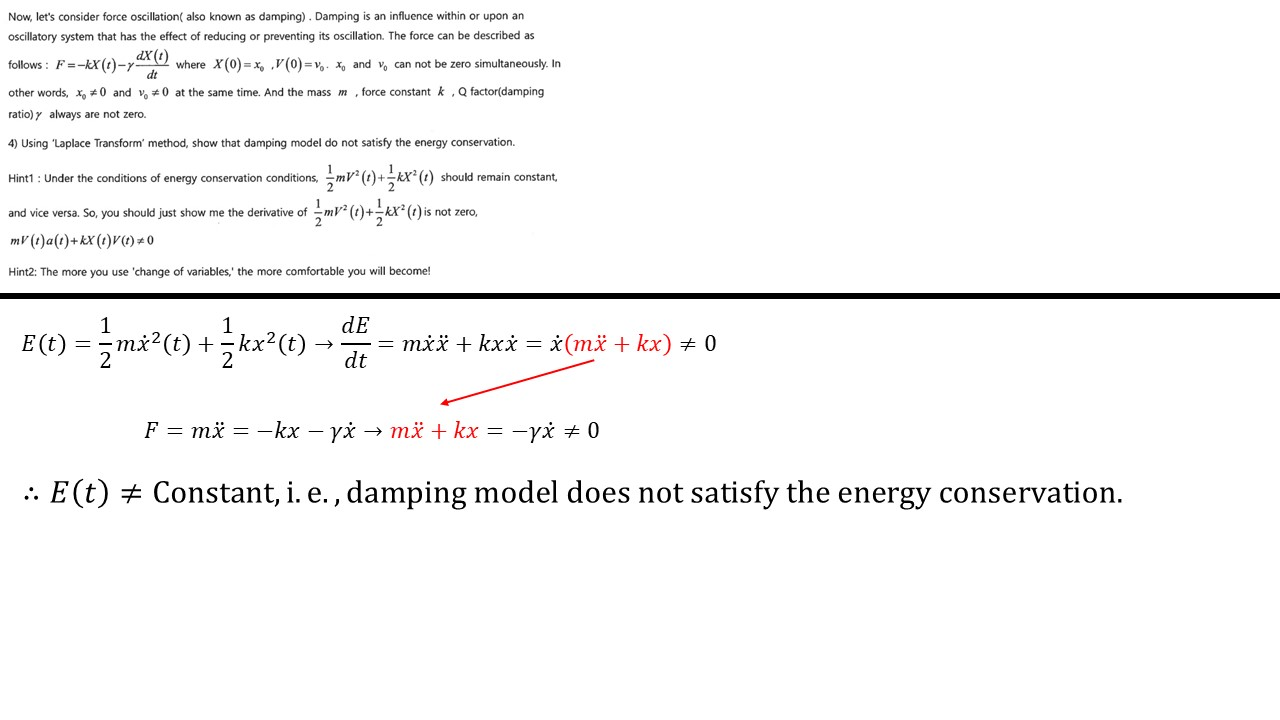

### 위에처럼 energy가 보존이 안된다는 것은 몇줄 안에 증명이 가능하나, 한번 노가다식 계산을 아래와 같이 해봤습니다.

### (이걸 해야 뒤에 $x(t)$ 같은 그래프를 그릴 수 있기에..)

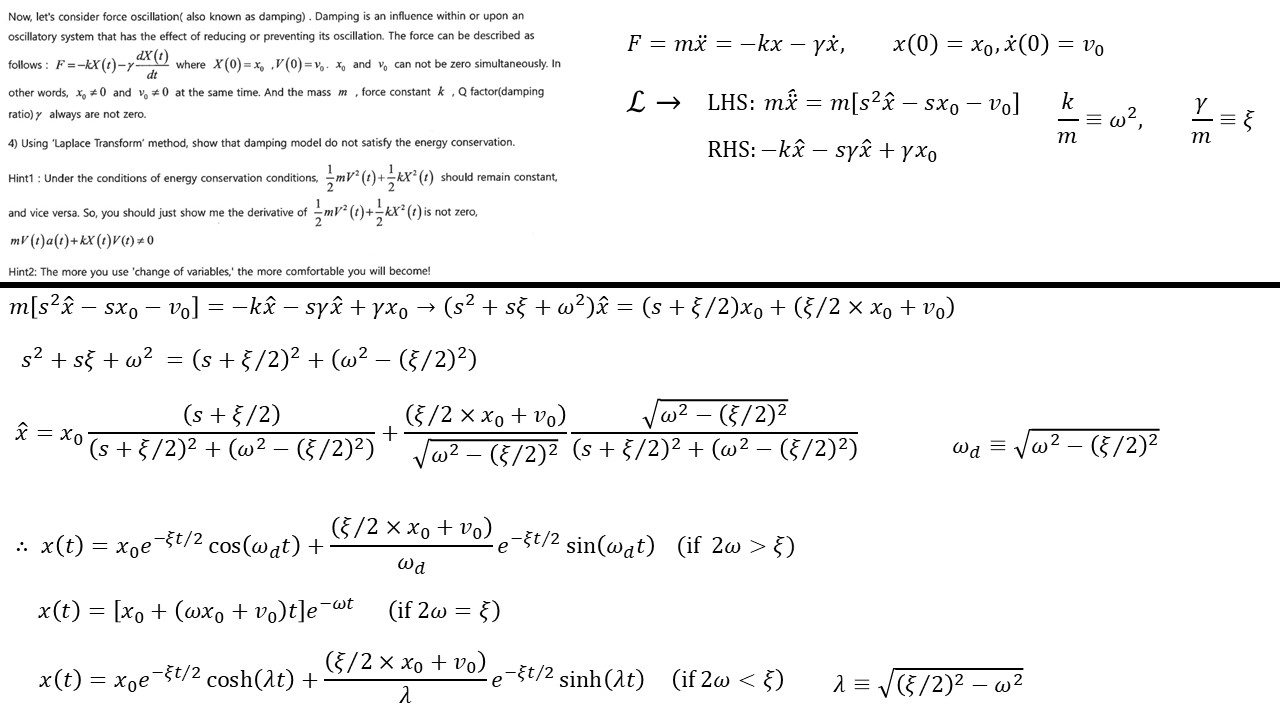

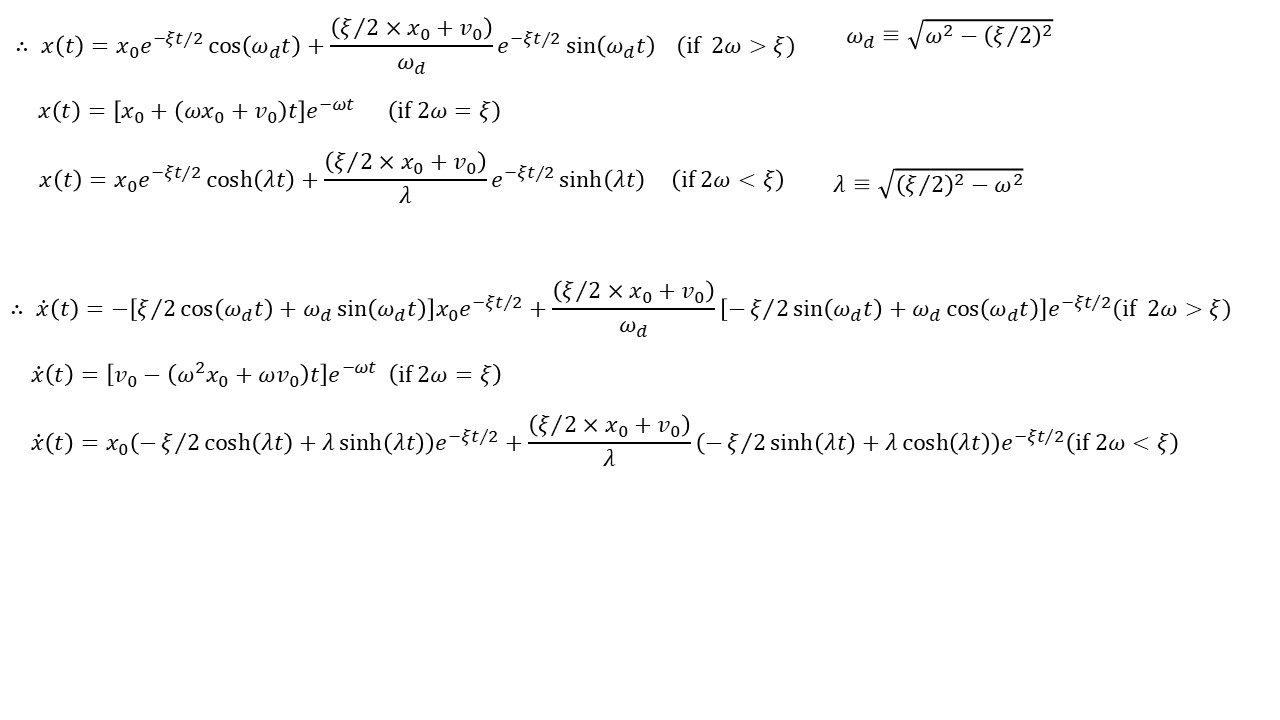

#Harmonic Oscillator와 RLC 회로의 유사성

Harmonic oscillator와 RLC 회로는 물리적 및 수학적으로 유사한 동작을 보이는 시스템으로, 두 시스템은 모두 진동 또는 진동의 감쇠를 설명하는 데 사용됩니다.

# 1. 감쇠가 있는 Harmonic Oscillator:
속도에 비례하는 저항력이 있는 조화 진동자의 운동 방정식은 다음과 같습니다:

$$m\frac{d^2x}{dt^2}+kx+\gamma \frac{dx}{dt}=0$$

여기서,

- $m$은 질량,
- $\gamma$는 감쇠 계수 (또는 저항 계수),
- $k$는 스프링 상수,
- $x(t)$는 변위입니다.

이 방정식은 감쇠된 조화 진동자를 설명하며, 감쇠 계수 $\gamma$는 시스템이 어떻게 에너지를 잃는지를 나타냅니다.

이 방정식에서 $\gamma \frac{dx}{dt}$ 항이 바로 속도에 비례하는 저항력(마찰력)을 나타냅니다.


# 2. RLC 회로:
RLC 회로에서의 운동 방정식은 다음과 같이 주어집니다:

$$L\frac{d^2q}{dt^2}+\frac{q}{C}+R \frac{dq}{dt}=0$$

여기서,

- $L$은 인덕턴스,
- $R$은 저항,
- $C$는 커패시턴스,
- $q(t)$는 시간에 따른 전하량입니다.



# 3. 두 시스템의 비교:
감쇠가 있는 조화 진동자와 RLC 회로는 수학적으로 동일한 형태의 2차 상미분 방정식으로 설명됩니다. 이 두 시스템 간의 대응 관계는 다음과 같습니다:

- 질량 $m$ ↔ 인덕턴스 $L$
- 감쇠 계수 $b$ ↔ 저항 $R$
- 스프링 상수 $k$ ↔ $1/C$(커패시턴스의 역수)


따라서, 속도에 비례하는 저항력을 포함한 조화 진동자의 운동 방정식은 RLC 회로의 방정식과 본질적으로 동일한 수학적 구조를 가집니다. 이로 인해, 이러한 시스템들은 진동, 감쇠, 그리고 공진 특성에 대해 유사한 물리적 및 수학적 해석을 가능하게 합니다.

# 아래는 위에서 풀어본 결과를 시각화해주는 python code입니다.

# 한번 변수들을 조절해보면서 어떤 결과가 나오는지 확인해보세요.!!

# time-dependent $x(t)$ (position)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Derived parameters function
def derived_params(k, m, gamma):
    ω = np.sqrt(k / m)
    ξ = gamma / m
    return ω, ξ

# Define the damped harmonic oscillator function for underdamped, critically damped, and overdamped
def x_t(t, x0, v0, ω, ξ):
    if ξ < 2 * ω:  # Underdamped
        ω_d = np.sqrt(ω**2 - (ξ / 2)**2)
        term1 = x0 * np.exp(-ξ * t / 2) * np.cos(ω_d * t)
        term2 = (v0 + (ξ / 2) * x0) / ω_d * np.exp(-ξ * t / 2) * np.sin(ω_d * t)
        return term1 + term2
    elif ξ == 2 * ω:  # Critically damped
        term1 = (x0 + (v0 + ω * x0) * t) * np.exp(-ω * t)
        return term1
    else:  # Overdamped
        λ = np.sqrt((ξ / 2)**2 - ω**2)
        term1 = x0 * np.exp(-ξ * t / 2) * np.cosh(λ * t)
        term2 = (v0 + (ξ / 2) * x0) / λ * np.exp(-ξ * t / 2) * np.sinh(λ * t)
        return term1 + term2

def v_t(t, x0, v0, ω, ξ):
    if ξ < 2 * ω:  # Underdamped
        ω_d = np.sqrt(ω**2 - (ξ / 2)**2)
        term1 = -x0 * ((ξ / 2) * np.cos(ω_d * t) + ω_d * np.sin(ω_d * t)) * np.exp(-ξ * t / 2)
        term2 = (v0 + (ξ / 2) * x0) / ω_d * (-(ξ / 2) * np.sin(ω_d * t) + ω_d * np.cos(ω_d * t)) * np.exp(-ξ * t / 2)
        return term1 + term2
    elif ξ == 2 * ω:  # Critically damped
        term1 = (v0 - (ω**2 * x0 + ω * v0) * t) * np.exp(-ω * t)
        return term1
    else:  # Overdamped
        λ = np.sqrt((ξ / 2)**2 - ω**2)
        term1 = x0 * (-ξ / 2 * np.cosh(λ * t) + λ * np.sinh(λ * t)) * np.exp(-ξ * t / 2)
        term2 = (v0 + (ξ / 2) * x0) / λ * (-ξ / 2 * np.sinh(λ * t) + λ * np.cosh(λ * t)) * np.exp(-ξ * t / 2)
        return term1 + term2

# Plotting function
def plot_damped_oscillator(x0, v0, k, m, gamma):
    ω, ξ = derived_params(k, m, gamma)
    t = np.linspace(0, 20, 400)
    x = x_t(t, x0, v0, ω, ξ)

    plt.figure(figsize=(10, 6))
    plt.plot(t, x, label='$x(t)$')
    plt.title('Damped Harmonic Oscillator')
    plt.xlabel('Time $t$')
    plt.ylabel('Displacement $x(t)$')
    plt.grid(True)
    plt.legend()
    plt.show()

# Create interactive widgets
interact(
    plot_damped_oscillator,
    x0=FloatSlider(value=1.0, min=0, max=2, step=0.1, description='x_0'),
    v0=FloatSlider(value=0.5, min=-2, max=2, step=0.1, description='v_0'),
    k=FloatSlider(value=2.0, min=0.1, max=5, step=0.1, description='k'),
    m=FloatSlider(value=1.0, min=0.1, max=5, step=0.1, description='m'),
    gamma=FloatSlider(value=0.5, min=0, max=5, step=0.1, description='γ')
)


interactive(children=(FloatSlider(value=1.0, description='x_0', max=2.0), FloatSlider(value=0.5, description='…

<function __main__.plot_damped_oscillator(x0, v0, k, m, gamma)>

# time-dependent $v(t)$ (velocity)

In [2]:
# Plotting function
def plot_damped_oscillator_velocity(x0, v0, k, m, gamma):
    ω, ξ = derived_params(k, m, gamma)
    t = np.linspace(0, 20, 400)
    v = v_t(t, x0, v0, ω, ξ)


    plt.figure(figsize=(10, 6))
    plt.plot(t, v, label='$v(t)$')
    plt.title('Damped Harmonic Oscillator')
    plt.xlabel('Time $t$')
    plt.ylabel('velocity')
    plt.grid(True)
    plt.legend()
    plt.show()

# Create interactive widgets
interact(
    plot_damped_oscillator_velocity,
    x0=FloatSlider(value=1.0, min=0, max=2, step=0.1, description='x_0'),
    v0=FloatSlider(value=0.5, min=-2, max=2, step=0.1, description='v_0'),
    k=FloatSlider(value=2.0, min=0.1, max=5, step=0.1, description='k'),
    m=FloatSlider(value=1.0, min=0.1, max=5, step=0.1, description='m'),
    gamma=FloatSlider(value=0.5, min=0, max=5, step=0.1, description='γ')
)


interactive(children=(FloatSlider(value=1.0, description='x_0', max=2.0), FloatSlider(value=0.5, description='…

<function __main__.plot_damped_oscillator_velocity(x0, v0, k, m, gamma)>

# time-dependent $E(t)$ (Energy)

In [3]:
# Plotting function
def plot_damped_oscillator_energy(x0, v0, k, m, gamma):
    ω, ξ = derived_params(k, m, gamma)
    t = np.linspace(0, 20, 400)
    x = x_t(t, x0, v0, ω, ξ)
    v = v_t(t, x0, v0, ω, ξ)

    KE = 1/2 * m * v**2
    PE = 1/2 * k * x**2
    energy = KE + PE

    plt.figure(figsize=(10, 6))
    plt.plot(t, KE, label='$Kinetic E(t)$')
    plt.plot(t, PE, label='$Potential E(t)$')
    plt.plot(t, energy, label='$E(t)$')
    plt.title('Damped Harmonic Oscillator')
    plt.xlabel('Time $t$')
    plt.ylabel('Energy')
    plt.grid(True)
    plt.legend()
    plt.show()

# Create interactive widgets
interact(
    plot_damped_oscillator_energy,
    x0=FloatSlider(value=1.0, min=0, max=2, step=0.1, description='x_0'),
    v0=FloatSlider(value=0.5, min=-2, max=2, step=0.1, description='v_0'),
    k=FloatSlider(value=2.0, min=0.1, max=5, step=0.1, description='k'),
    m=FloatSlider(value=1.0, min=0.1, max=5, step=0.1, description='m'),
    gamma=FloatSlider(value=0.5, min=0, max=5, step=0.1, description='γ')
)


interactive(children=(FloatSlider(value=1.0, description='x_0', max=2.0), FloatSlider(value=0.5, description='…

<function __main__.plot_damped_oscillator_energy(x0, v0, k, m, gamma)>